In [1]:
import cornac
from cornac.data import Reader
from cornac.datasets import movielens
from cornac.data import Dataset, FeatureModality
from cornac.eval_methods import RatioSplit, StratifiedSplit
from cornac.metrics import RMSE,AUC,NDCG,Precision,Recall
from cornac.models import MF, ItemKNN, UserKNN, NMF, BPR
import pandas as pd
import numpy as np
import random
import math
import seaborn as sns
import matplotlib.pyplot as plt

/Users/tahsinalamgirkheya/anaconda3/envs/cornac/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# reader = Reader()
# # file_name= "./cornac/data_c/indexed_interactions.csv"
# file_name= "biased_movie_lens.csv"
# rating_data_pd = pd.read_csv(
#     file_name,
#     sep=",",
#     header=None,
#     names=["_","userID", "itemID", "Rating", "Timestamp", "movieID","genres","Drama","Children's","Action","War","Documentary","Animation","Comedy","Sci-Fi","Romance","Musical","Western","Crime","Thriller","Adventure","Fantasy","Mystery","Film-Noir","Horror","Gender"],
#     dtype={"userID":int, "itemID":int, "Rating":int, "Timestamp":int, "movieID":int,"Drama":float,"Children's":float,"Action":float,"War":float,"Documentary":float,"Animation":float,"Comedy":float,"Sci-Fi":float,"Romance":float,"Musical":float,"Western":float,"Crime":float,"Thriller":float,"Adventure":float,"Fantasy":float,"Mystery":float,"Film-Noir":float,"Horror":float, "Gender":int}
# )
# rating_data = rating_data_pd[["userID","itemID","Rating","Timestamp"]].to_numpy()
# rating_data
# # rating_data = rating_data.drop(columns=rating_data.columns[-1])
# # ,userID,itemID,Rating,Timestamp,movieID,genres,Drama,Children's,Action,War,Documentary,Animation,Comedy,Sci-Fi,Romance,Musical,Western,Crime,Thriller,Adventure,Fantasy,Mystery,Film-Noir,Horror,Gender
# rating_data_pd
# # user id itemid rating and timestamp

In [2]:
reader = Reader()
rating_data_pd = pd.read_csv(
    "./cornac/data_c/indexed_interactions.csv",
    sep="\t",
    header=None,
    names=["userID", "itemID", "Rating", "Timestamp"],
)
# print(rating_data["itemID"].nunique())
# rating_data = rating_data.drop(columns=rating_data.columns[-1])
rating_data = rating_data_pd.to_numpy()
rating_data

array([[        0,         0,         5, 978300760],
       [        0,         1,         3, 978302109],
       [        0,         2,         3, 978301968],
       ...,
       [     6039,       365,         5, 956704746],
       [     6039,       152,         4, 956715648],
       [     6039,        26,         4, 956715569]])

In [3]:
# dataset = Dataset.from_uirt(rating_data, reader=reader)
dataset = rating_data

In [4]:
# movie_data = reader.read(fpath="./data/indexed_movies.csv", sep=",", fmt="UIRT")
# movie_data
movies = pd.read_csv("./cornac/data_c/indexed_movies.csv")

movies = movies.drop(columns=movies.columns[0])
movies[:4]

unique_genres = set("|".join(movies["genres"]).split("|"))
unique_genres = list(unique_genres)

for genre in unique_genres:
    movies[genre] = 0
for index, row in movies.iterrows():
    genres = row["genres"].split("|")
    for genre in genres:
        movies.at[index, genre] = 1

# item_categories = movies[unique_genres]
# unique_iids = rating_data_pd['itemID'].unique()
# movies = movies[movies['itemID'].isin(unique_iids)]
genre = movies[unique_genres]
item_features_numpy = genre.to_numpy()
# print(item_features_numpy.shape)

# item_categories = item_categor
item_features = {
    str(item_id): {"genre_" + str(idx): value for idx, value in enumerate(row)}
    for item_id, row in enumerate(item_features_numpy)
}
ids = list(range(0, 3416))
item_feature_modality = FeatureModality(
    features=item_features_numpy, ids=ids, normalized=True
)


users = pd.read_csv("./cornac/data_c/u_id_mapping.csv", sep="\t")
users = users.drop(columns=users.columns[0])
gender_map = {"M": 0, "F": 1}
users["Gender"] = users["Gender"].map(gender_map)
# unique_uids = rating_data_pd['userID'].unique()

# users = users[users["userID"].isin(unique_uids)]
user_features_numpy = users.to_numpy()
print(user_features_numpy.shape)
print(item_features_numpy.shape)
user_feature_modality = FeatureModality(
    features=user_features_numpy, name="user", normalized=True, ids=list(range(0, 6040))
)

# print("Example Item Features:")
# for item_id, features in list(item_features.items())[:5]:
#     print(f"Item ID: {item_id}, Features: {features}")

(6040, 2)
(3416, 18)


In [5]:
# inter_movies = pd.merge(rating_data_pd, movies, on="itemID", how="inner")
# inter_movies = pd.merge(inter_movies, users, on="userID", how="inner")
# inter_movies
movies

,movieID,genres,itemID,Film-Noir,Mystery,Animation,Western,Documentary,Children's,Sci-Fi,...,Fantasy,Crime,Romance,Adventure,Thriller,Horror,War,Drama,Musical,Comedy
0,1193,Drama,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,661,Animation|Children's|Musical,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
2,914,Musical|Romance,2,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,0
3,3408,Drama,3,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
4,2355,Animation|Children's|Comedy,4,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3411,2833,Romance|War,3411,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
3412,3207,Adventure,3412,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3413,3533,Drama,3413,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3414,2777,Drama,3414,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [7]:
# new_df = inter_movies.groupby("userID")[unique_genres].sum()
# new_df = pd.merge(new_df, users, on="userID", how="inner")
# new_df = inter_movies.groupby("Gender")[unique_genres].sum()
# new_df


In [8]:
# genre_to_remove_m=["Romance", "Drama","Comedy", "Musical"]
# genre_to_remove_f=["Action", "War","Thriller", "Horror"]
# # upper_bound = inter_movies.shape[0]
# indices_to_delete = set()
# mask_f = (inter_movies['Gender'] == 1) & (inter_movies[genre_to_remove_f].sum(axis=1) > 0)
# mask_m = (inter_movies['Gender'] == 0) & (inter_movies[genre_to_remove_m].sum(axis=1) > 0)
# mask_f = inter_movies.index[mask_f]
# mask_m = inter_movies.index[mask_m]
# upper_bound_m = mask_m.__len__()
# upper_bound_f = mask_f.__len__()
# for i in range(100000):
#     rm=random.randint(0, upper_bound_m-1)
#     rf=random.randint(0, upper_bound_f-1)
#     indices_to_delete.add(mask_f[rf])
#     indices_to_delete.add(mask_m[rm])
            
# inter_movies = inter_movies.drop(indices_to_delete, axis=0).reset_index(drop=True)
# # sales.drop(sales[sales.CustomerId.isin(badcu)].index.tolist()

In [9]:
# inter_movies
# unique_iids = inter_movies['userID'].unique()
# unique_iids.__len__()
# # movies = movies[movies['itemID'].isin(unique_iids)]


In [11]:
ratio_split = StratifiedSplit(
    data=dataset,
    test_size=0.2,
    rating_threshold=0.0,
    seed=123,
    verbose=True,
    chrono=True,
    user_features=user_features_numpy[:, 1],
    item_features=item_features_numpy,exclude_unknowns=False
)
rec_50 = cornac.metrics.Recall(k=50)
ndcg_50 = cornac.metrics.NDCG(k=50)
auc = cornac.metrics.AUC()
rmse = cornac.metrics.RMSE()
prec = cornac.metrics.Precision(k=50)


models=[]
# alpha_values=[0.5,0]
# for i in range(len(alpha_values)):
#     model = MF(
#     k=20,
#     max_iter=50,
#     learning_rate=0.00001,
#     lambda_reg=0.02,
#     seed=123,
#     name="alpha="+str(alpha_values[i]),
#     backend="pytorch",
#     alpha=alpha_values[i]
#     )    
#     models.append(model)

model = UserKNN(k=20, seed=123)
# model = UserKNN(k=20, seed=123)
# model_2 = MF(
# k=10,
# max_iter=50,
# learning_rate=0.0001,
# lambda_reg=0.02,
# seed=123,
# name="alpha="+str(alpha_values[1]),
# backend="pytorch",
# optimizer="sgd",
# alpha=alpha_values[1],
# ) 

models.append(model)


cornac.Experiment(
    ratio_split, models=models, metrics=[rec_50,ndcg_50,auc,rmse,prec]
).run()

rating_threshold = 0.0
exclude_unknowns = False
::::::::
OrderedDict()
OrderedDict()
::::::::
---
Training data:
Number of users = 6040
Number of items = 3415
Number of ratings = 797275
Max rating = 5.0
Min rating = 1.0
Global mean = 3.6
::::::::
OrderedDict([(6039, 0), (6038, 1), (6037, 2), (6036, 3), (6035, 4), (6034, 5), (6033, 6), (6032, 7), (6031, 8), (6030, 9), (6029, 10), (6028, 11), (6027, 12), (6026, 13), (6025, 14), (6024, 15), (6023, 16), (6022, 17), (6021, 18), (6020, 19), (6019, 20), (6018, 21), (6017, 22), (6016, 23), (6015, 24), (6014, 25), (6013, 26), (6012, 27), (6011, 28), (6010, 29), (6009, 30), (6008, 31), (6006, 32), (6007, 33), (6005, 34), (6004, 35), (6003, 36), (6002, 37), (6001, 38), (6000, 39), (5999, 40), (5998, 41), (5997, 42), (5996, 43), (5995, 44), (5994, 45), (5993, 46), (5992, 47), (5991, 48), (5990, 49), (5989, 50), (5988, 51), (5987, 52), (5986, 53), (5985, 54), (5983, 55), (5982, 56), (5981, 57), (5980, 58), (5978, 59), (5979, 60), (5977, 61), (5976,

100%|██████████| 6040/6040 [01:09<00:00, 86.46it/s] 



[UserKNN] Evaluation started!


Ranking: 100%|██████████| 6040/6040 [03:27<00:00, 29.17it/s]


TEST:
...
        |   RMSE |    AUC | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
UserKNN | 0.9401 | 0.6282 |  0.0242 |       0.0186 |    0.0383 |   70.7466 | 220.8322



In [ ]:
          |   RMSE |    AUC | NDCG@20 | Precision@20 | Recall@20 | Train (s) | Test (s)
--------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
alpha=0   | 1.0738 | 0.5781 |  0.0651 |       0.0433 |    0.0619 |  265.6354 |   2.8158
alpha=0.3 | 1.0739 | 0.5719 |  0.0625 |       0.0413 |    0.0588 |   89.6387 |   2.9407
alpha=0.5 | 1.0740 | 0.5642 |  0.0579 |       0.0371 |    0.0537 |   89.0614 |   3.5518
alpha=0.7 | 1.0740 | 0.5504 |  0.0444 |       0.0265 |    0.0392 |   87.0882 |   2.8338
alpha=0.8 | 1.0741 | 0.5389 |  0.0300 |       0.0182 |    0.0264 |  672.8500 |   2.8299

new dataset



# item knn no modificatin
        |   RMSE |    AUC | NDCG@20 | Precision@20 | Recall@20 | Train (s) | Test (s)
------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
UserKNN | 0.9469 | 0.6237 |  0.0103 |       0.0121 |    0.0103 |    1.8950 | 159.0414

# after adding item genres
        |   RMSE |    AUC | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
ItemKNN | 1.0084 | 0.5599 |  0.0173 |       0.0133 |    0.0203 |  156.3764 | 116.4956


# after adding user info
        |   RMSE |    AUC | NDCG@50 | Precision@50 | Recall@50 | Train (s) | Test (s)
------- + ------ + ------ + ------- + ------------ + --------- + --------- + --------
UserKNN | 0.9339 | 0.6007 |  0.0072 |       0.0041 |    0.0154 |   33.4947 | 123.2689


#------------------
          |   RMSE |    AUC | NDCG@20 | Recall@20 | Train (s) | Test (s)
--------- + ------ + ------ + ------- + --------- + --------- + --------
alpha=0   | 1.0809 | 0.5798 |  0.1018 |    0.0635 |  152.5753 |   3.6027
alpha=0.8 | 1.0847 | 0.5844 |  0.1024 |    0.0645 |  211.1065 |   4.3291

          |   RMSE |    AUC | NDCG@20 | Recall@20 | Train (s) | Test (s)
--------- + ------ + ------ + ------- + --------- + --------- + --------
alpha=0.3 | 1.0823 | 0.5800 |  0.1016 |    0.0640 |  772.8089 |   3.6702
alpha=0.5 | 1.0832 | 0.5806 |  0.1018 |    0.0644 |  169.9725 |   4.7815

for (m-f)^2
#------------------


In [ ]:
# # choose movies that are only available in the biased subset
# unique_iids = rating_data_pd['itemID'].unique()
# unique_uids = rating_data_pd['userID'].unique()
# movies = movies[movies['itemID'].isin(unique_iids)]
# users = users[users["userID"].isin(unique_uids)]
# # 
# users
# # cols_to_select = unique_genres +["itemID", "genres"]
# # new_movies = new_movies[cols_to_select]

6040

In [20]:
# get the top_k ratings for all users:
top_k = 50
reco_matrix = np.zeros((len(user_ids), top_k), dtype=int)
reco_matrix_all_scores = np.zeros((len(user_ids), len(item_ids)), dtype=int)
reco_matrix_all_items = np.zeros((len(user_ids), len(item_ids)), dtype=int)

for i in range(len(user_ids)):
    reco_items, all_scores = models[0].rank(user_idx=user_ids[i], item_indices=list(item_ids))
    reco_matrix[i] = reco_items[:top_k]
    reco_matrix_all_scores[i] = all_scores
    reco_matrix_all_items[i] = reco_items

3416

In [13]:
# # get the top_k ratings for all users:
# top_k = 50
# reco_matrix = np.zeros((len(models), len(user_ids), top_k), dtype=int)


# for u in user_ids:
#     for i in range(len(models)):
#         reco_items, all_scores = models[i].rank(user_idx=u, item_indices=list(item_ids))
#         reco_matrix[i][u] = reco_items[:top_k]

KeyboardInterrupt: 

In [21]:
####Import Metrics####
from cornac.mymetrics.GenrePrecision import GenrePrecision
from cornac.mymetrics.GenreMap import GenreMap
from cornac.mymetrics.GenreMRR import GenreMRR
from cornac.mymetrics.GenreNDCG import GenreNDCG
from cornac.mymetrics.GenreRecall import GenreRecall
from cornac.mymetrics.GenreRPrecision import GenreRPrecision

###intialize them 
gp = GenrePrecision(users, unique_genres)
gr = GenreRecall(users, unique_genres)
gm = GenreMap(users, unique_genres)
gndcg = GenreNDCG(users, unique_genres)
gmrr = GenreMRR(users, unique_genres)

In [22]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
movies_df = movies_df[unique_genres].sum()
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r = np.zeros((len(user_ids), new_top_k), dtype=int)

for i in range(len(user_ids)):
    reco_items, all_scores = models[0].rank(user_idx=user_ids[i], item_indices=list(item_ids))
    reco_matrix_top_r[i] = reco_items[:new_top_k]


grp = GenreRPrecision(users, unique_genres)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

In [23]:
# for r-precision we wanna take the max of the proportiion of total genre in the movie dataset using ranks
movies_df = movies[unique_genres].div(movies[unique_genres].sum(axis=1), axis=0)
movies_df = movies_df[unique_genres].sum()
new_top_k = math.floor(movies_df.max())


# get the top_k ratings for all users:
reco_matrix_top_r_2 = np.zeros((len(user_ids), new_top_k), dtype=int)

for i in range(len(user_ids)):
    reco_items, all_scores = models[1].rank(user_idx=user_ids[i], item_indices=list(item_ids))
    reco_matrix_top_r_2[i] = reco_items[:new_top_k]


grp = GenreRPrecision(users, unique_genres)
# MF_grp = grp.compute(reco_matrix_top_r, movies_df, movies)

IndexError: list index out of range

In [26]:
####IR Metrics####
####Precision####
model_gp = gp.compute(reco_matrix, movies)
# model_gp_2 = gp.compute(reco_matrix[1], movies)
####IR Metrics####
####Recall####
model_gr = gr.compute(reco_matrix, movies)
# model_gr_2 = gr.compute(reco_matrix[1], movies)
####IR Metrics####
####MAP Mean Average Precision####
model_gm = gm.compute(reco_matrix, movies)
# model_gm_2 = gm.compute(reco_matrix[1], movies)
####IR Metrics####
####DCG####
model_gdcg = gndcg.compute(reco_matrix, movies)
# model_gdcg_2 = gndcg.compute(reco_matrix[1], movies)
####IR Metrics####
####MRR####
model_gmrr = gmrr.compute(reco_matrix, movies)
# model_gmrr_2 = gmrr.compute(reco_matrix[1], movies)

        Film-Noir     Comedy  Animation     Crime  Thriller   Western  \
userID                                                                  
0        0.000000   8.083333   3.250000  0.500000  2.333333  1.666667   
1        0.333333   6.366667   1.200000  0.500000  2.666667  1.000000   
2        0.000000  12.450000   1.533333  1.000000  1.000000  3.000000   
3        0.000000  10.533333   0.533333  1.250000  3.250000  1.500000   
4        0.666667  15.200000   1.533333  1.000000  1.333333  1.000000   
...           ...        ...        ...       ...       ...       ...   
6035     0.000000  12.700000   1.533333  1.333333  1.000000  2.000000   
6036     0.333333  12.866667   1.533333  1.500000  2.333333  1.000000   
6037     0.000000  10.666667   1.583333  0.000000  3.250000  2.333333   
6038     0.000000   7.833333   2.166667  0.250000  4.333333  2.000000   
6039     0.666667  11.200000   0.700000  1.000000  1.166667  2.333333   

        Children's       War   Musical  Documentar

In [27]:

# ####IR Metrics####
# ####Rprecision####
model_grp = grp.compute(reco_matrix_top_r, movies_df, movies)
# model_grp_2 = grp.compute(reco_matrix_top_r_2, movies_df, movies)

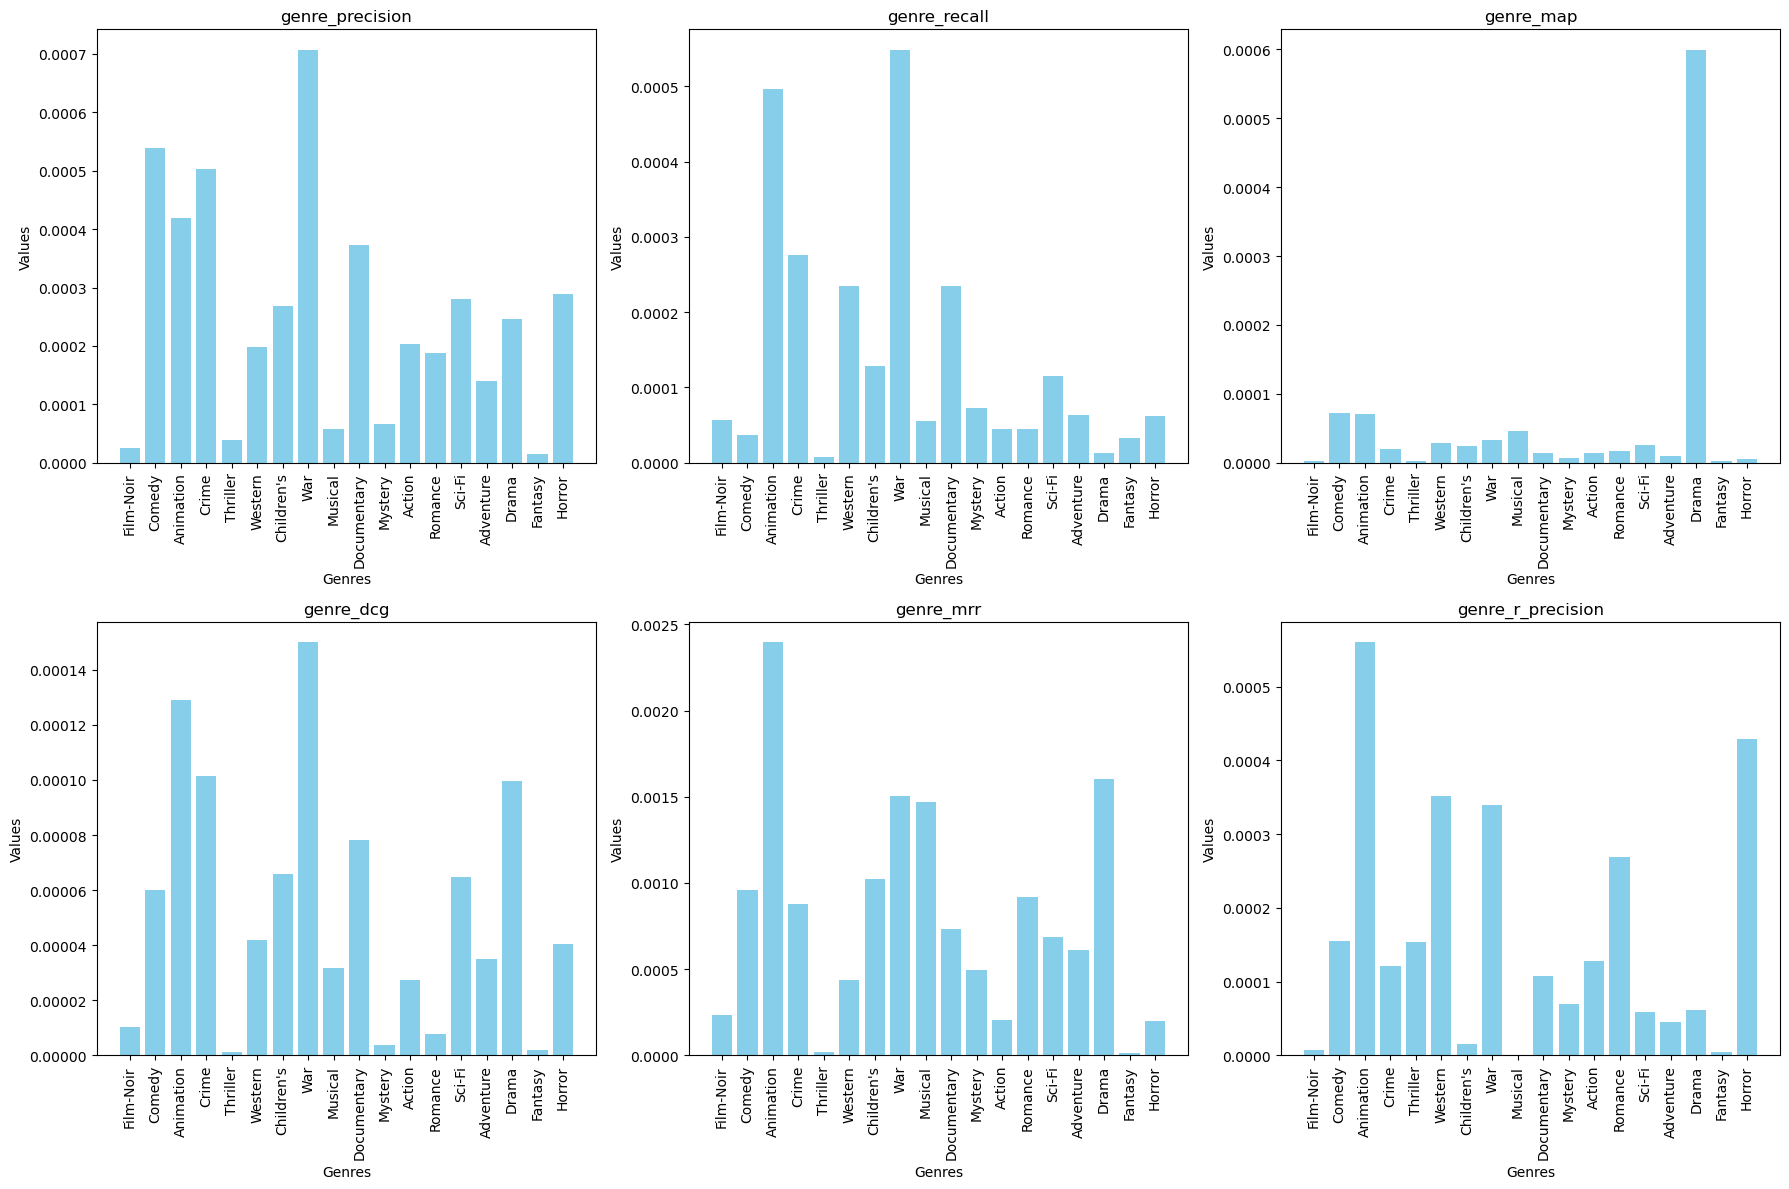

In [28]:
import matplotlib.pyplot as plt
import numpy as np



matrices =[model_gp,model_gr,model_gm,model_gdcg,model_gmrr,model_grp]

# values2 = matrices[1]
labels = unique_genres
bar_width = 0.25
titles = [ "genre_precision","genre_recall","genre_map","genre_dcg","genre_mrr","genre_r_precision"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(titles)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

In [31]:
reco_matrix_all_scores

array([[4, 4, 3, ..., 2, 5, 0],
       [4, 4, 3, ..., 3, 5, 1],
       [4, 4, 3, ..., 3, 3, 1],
       ...,
       [3, 3, 2, ..., 2, 5, 0],
       [4, 3, 3, ..., 3, 5, 0],
       [4, 3, 3, ..., 3, 5, 1]])

In [32]:
reco_matrix_all_items

array([[3414, 3230, 3382, ..., 2834, 3191, 3415],
       [3414, 3230, 3382, ..., 2834, 3191, 3415],
       [3230, 3382,   13, ..., 3191, 2834, 3415],
       ...,
       [3414, 3230, 3382, ..., 2834, 3191, 3415],
       [3414, 3230, 3354, ..., 2834, 3191, 3415],
       [3414, 3230, 3354, ..., 2834, 3191, 3415]])

In [38]:
itemknn = matrices
itemknn

[array([2.52699421e-05, 5.38335919e-04, 4.18371471e-04, 5.02272210e-04,
        3.96816272e-05, 1.97881679e-04, 2.68782664e-04, 7.06700556e-04,
        5.83239289e-05, 3.72770827e-04, 6.69145474e-05, 2.03775522e-04,
        1.88443775e-04, 2.80164631e-04, 1.39942933e-04, 2.46834536e-04,
        1.47538146e-05, 2.89574343e-04]),
 array([5.72149633e-05, 3.64759183e-05, 4.96681604e-04, 2.76125459e-04,
        7.96499944e-06, 2.34642307e-04, 1.28830163e-04, 5.48396707e-04,
        5.51787407e-05, 2.34447061e-04, 7.28123475e-05, 4.53640966e-05,
        4.46549230e-05, 1.15500054e-04, 6.35622707e-05, 1.28394703e-05,
        3.29571437e-05, 6.18704529e-05]),
 array([3.02076309e-06, 7.22572510e-05, 7.04398160e-05, 2.04782267e-05,
        3.20277269e-06, 2.80516375e-05, 2.40028354e-05, 3.25508046e-05,
        4.56744341e-05, 1.38030631e-05, 6.20398007e-06, 1.35226678e-05,
        1.74397456e-05, 2.53655989e-05, 9.45475957e-06, 5.99141770e-04,
        2.20683686e-06, 5.78651323e-06]),
 array([1.

In [ ]:
s=0
for i in range(len(titles)):
    s=sum(MF_0_5[i])+s
print(s)

1.131974830710647e-16


In [33]:

s=0
for i in range(len(titles)):
    print(sum(MF_0[i]))
    s=sum(MF_0[i])+s
print(s)

0.004558794925673907
0.002525518681453498
0.000992603476589191
0.0009499180066664342
0.014391470894008308
0.0028761175084075132
0.026294423492798855


In [6]:
reco_matrix_all_items=np.load('reco_matrix_all_items.npy' )
reco_matrix_all_scores=np.load('reco_matrix_all_scores.npy' )
itemknn=np.load('itemknn.npy' )

#reco_matrix_all_items

In [17]:

top_k = 50
reco_matrix = np.zeros((reco_matrix_all_items.shape[0], top_k), dtype=int)
for i in range(reco_matrix_all_items.shape[0]):
    reco_matrix[i] = reco_matrix_all_items[i][:top_k]

In [19]:
reco_matrix.shape

(6040, 50)

In [45]:
# tahsin kheya
# last modified 21/05/2024
import pandas as pd
import os
import numpy as np
import torch
import time
from logging import getLogger


class Calibration(object):
    def __init__(self, config, movies,top_k,unique_genres,users):
        # self.logger = getLogger()
        self.reco_distribution = []
        self.kl = []
        self.unique_genres=unique_genres
        # self.logger = getLogger()
        self.top_k=top_k
        self.gkl = []
        self.gender_df = users
        self.actual_genre_dist = pd.read_csv(
            os.path.join(config["user_genre_dist_file"]),
            sep="\t",
        )
        self.config = config
        self.item_df = movies
        self.actual_distribution = self.actual_genre_dist.to_numpy()
        self.actual_distribution_gender = []

    def get_all_user_recommended_genre_dist(self, topk_reco):

        df_reco = pd.DataFrame(
            {
                "userID": np.repeat(
                    np.arange(topk_reco.shape[0]), self.top_k
                ),
                "itemID": topk_reco.flatten(),
                "rank": np.tile(
                    np.arange(1, self.top_k + 1), topk_reco.shape[0]
                ),
            }
        )
        df_reco["weight_factor"] = 1 / (df_reco["rank"]) ** 0.1
        merged_df = pd.merge(df_reco, self.item_df, on="itemID", how="inner")
        merged_df[self.unique_genres] = merged_df[
            self.unique_genres
        ].div(merged_df[self.unique_genres].sum(axis=1), axis=0)
        merged_df[self.unique_genres] = (
            merged_df["weight_factor"].values[:, None]
            * merged_df[self.unique_genres]
        )
        reco_distribution = merged_df[["userID"] + self.unique_genres]
        reco_distribution = reco_distribution.groupby("userID")[
            self.unique_genres
        ].mean()
        reco_distribution[self.unique_genres] = reco_distribution[
            self.unique_genres
        ].div(reco_distribution[self.unique_genres].sum(axis=1), axis=0)

        return reco_distribution

    def get_recom_distribution(self, reco):
        reco = np.array(reco)
        weights = 1 / (np.arange(len(reco)) + 1) ** 0.1
        item_genre_weights = np.zeros((len(reco), len(self.unique_genres)))
        for i, itemID in enumerate(reco):
            item_index = self.item_df.index.get_loc(itemID)
            item_genre_weights[i] = (
                weights[i] * self.item_df.loc[item_index, self.unique_genres]
            )
        # Normalize genre weights so sum is 1
        item_genre_weights /= np.sum(item_genre_weights, axis=1, keepdims=True)
        return item_genre_weights

    def get_kl_div(self, q_dist, p_dist, a, uid):
        kl_div = 0
        qg_u = (1 - a) * q_dist + a * p_dist
        nonzero_indices = np.where(p_dist != 0)
        kl_div = np.sum(
            p_dist[nonzero_indices]
            * np.log10(p_dist[nonzero_indices] / qg_u[nonzero_indices])
        )

        return kl_div

    def get_gender_representation_one_user(self, reco_dist, uid):
        c = []
        retVal = []
        print(self.actual_distribution[uid])

        for i in range(len(self.unique_genres)):
            c.append(np.log(reco_dist[i] / self.actual_distribution[uid][i + 1]))
        # Assuming self.unique_genres is a list or array-like
        genre_columns_count = len(self.unique_genres)

        # Slice the necessary parts of reco_dist and actual_distribution
        reco_dist_slice = reco_dist[:genre_columns_count]
        actual_dist_slice = self.actual_distribution[uid][1 : genre_columns_count + 1]

        # Compute the logarithms of the ratio
        log_ratios = np.log(reco_dist_slice / actual_dist_slice)

        # Convert log_ratios to a list and append to retVal
        retVal.extend(log_ratios.tolist())

    def compute_diversity_score(self, reco_items, uid, l, scores, user_reco, b):

        # -----------------the diversity term----------------------------------
        alpha = 0.01
        # reco_items=self.reco_distribution[uid]
        sum_score = 0
        reco_dist = self.get_recom_distribution(reco_items)
        # print(reco_dist)
# 
        sum_dist = np.sum(reco_dist, axis=0)
        avg_dist = sum_dist / reco_dist.shape[0]
        # 1x18 array (it already is, but let's reshape explicitly)
        reco_dist = avg_dist.reshape(1, -1)
        # normalise values
        reco_dist = reco_dist / sum(reco_dist[0])

        kl = self.get_kl_div(
            reco_dist[0], self.actual_distribution[uid][1:], alpha, uid
        )
        # -----------------the diversity term----------------------------------

        # -----------------the fairness term----------------------------------
        # recommended dist mean for each gender
        male_user_ids=self.gender_df[self.gender_df["Gender"]==0]["userID"]
        male_user_ids=male_user_ids.to_list()
        gender_genre_dist = self.actual_distribution_gender
        # gender_reco_dist = self.get_gender_representation_one_user(reco_dist[0],uid)
        if uid in male_user_ids:
            compare_dist = gender_genre_dist.to_numpy()[1]
        else:
            compare_dist = gender_genre_dist.to_numpy()[0]

        gender_kl = self.get_kl_div(reco_dist[0], compare_dist, alpha, uid)

        # -----------------the fairness term----------------------------------

        for r in range(len(reco_items)):
            sum_score += scores[uid][reco_items[r]]

        # if len(reco_items) == 5:
        #     self.kl.append(kl)
        #     self.gkl.append(gender_kl)
        #     print(":;;;;;;;;;;;")
        #     print(uid)

        #     print(self.kl)
        #     print(self.gkl)
        #     print(":;;;;;;;;;;;")

        return (1 - l - b) * sum_score - l * kl - b * gender_kl
# c.get_improved_reco(reco_matrix,reco_matrix_all_items,reco_matrix_all_scores, users)

    def get_improved_reco(self, top_items,items, scores):
        
        # reco = torch.cat(batch_matrix_list, dim=0).cpu().numpy()

        # scores = torch.cat(batch_score_list, dim=0).cpu().numpy()
        # self.reco_distribution = self.get_recom_distribution(reco)
        return self.get_new_recommendations(reco=top_items, scores=scores, all_items=items)

    def get_kl_div_gender(self, female_dist, male_dist, a):
        kl_div = 0
        for i in range(len(self.unique_genres)):
            female_dist = (1 - a) * female_dist[i] + a * male_dist[i]
            if male_dist[i] == 0:
                continue
            kl_div = kl_div + male_dist[i] * np.log10(male_dist[i] / female_dist[i])

        return kl_div

    def get_gender_genre_dist(self, user_reco):
        # gender_df = pd.DataFrame(self.genders.items(), columns=["userID", "gender"])
        actual_dist_gender = pd.merge(self.actual_genre_dist, self.gender_df, on="userID")
        recomen_df = pd.merge(user_reco, self.gender_df, on="userID")
        # gender_genre_weights_r = recomen_df.groupby("gender")[
        #     self.unique_genres
        # ].mean()
        gender_genre_weights_a = actual_dist_gender.groupby("Gender")[
            self.unique_genres
        ].mean()
        self.actual_distribution_gender = gender_genre_weights_a.sort_index()

    def get_new_recommendations(self, reco, scores,all_items):
        """reco is 6040x50 and scores is 6040x3416"""
        

        user_reco_dist = self.get_all_user_recommended_genre_dist(reco)
        self.get_gender_genre_dist(user_reco_dist)

        # gender_discriminated_agaisnt = self.get_gender_discriminated_agaisnt(
        #     user_reco_dist
        # )
        # male_user_ids = [user_id for user_id, gender in self.genders.items() if gender == 0]
        # female_user_ids = [user_id for user_id, gender in self.genders.items() if gender == 1]
        # for each gender clculate the skew for each genre:
        l = 0.69  # lambda
        b = 0.29  # beta
        all_users = []
        # male_active_users= [4168,1679,4276]
        male_active_users = [4168]
        female_active_users = [1149]
        # female_active_users= [1149,1087,3223]
        male_inactive_users = [1712]
        # male_inactive_users= [1712,4067,2713]
        female_inactive_users = [2583]
        # female_inactive_users= [2583,2159,97]
        test_users = (
            male_active_users
            + female_active_users
            + male_inactive_users
            + female_inactive_users
        )
        top_k = self.top_k

        n_users, n_items = scores.shape

        for u in range(n_users):
            remaining_items = list(range(n_items))
            u_calibrated = []
            for k in range(top_k):
                diversity_scores = [
                    self.compute_diversity_score(
                        u_calibrated + [i], u, l, scores, user_reco_dist, b
                    )
                    for i in remaining_items
                ]

                max_index = np.argmax(diversity_scores)
                best_item = remaining_items[max_index]
                u_calibrated.append(best_item)
                remaining_items.pop(max_index)
                print(u_calibrated)
                # self.logger.info(u_calibrated)

            # self.logger.info(u_calibrated)

            all_users.append(u_calibrated)

        return np.array(all_users)


In [46]:
# from cornac.reranking.Calibration import Calibration
config = {"user_genre_dist_file":"./cornac/data_c/user_genre_dist.csv"}
c=Calibration(config=config, movies=movies,top_k=50, unique_genres=unique_genres, users=users)
c.get_improved_reco(reco_matrix,reco_matrix_all_items,reco_matrix_all_scores)

[474]
[474, 1575]
[474, 1575, 1000]
[474, 1575, 1000, 1120]
[474, 1575, 1000, 1120, 121]
[474, 1575, 1000, 1120, 121, 13]
[474, 1575, 1000, 1120, 121, 13, 1]
[474, 1575, 1000, 1120, 121, 13, 1, 3414]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11, 602]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11, 602, 259]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11, 602, 259, 192]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11, 602, 259, 192, 220]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11, 602, 259, 192, 220, 20]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11, 602, 259, 192, 220, 20, 441]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11, 602, 259, 192, 220, 20, 441, 396]
[474, 1575, 1000, 1120, 121, 13, 1, 3414, 15, 549, 11, 602, 259, 192, 220, 20, 441, 396, 2646]
[474, 1575, 1000, 1120, 121, 13

KeyboardInterrupt: 

In [47]:
pip show cornac

Name: cornac
Version: 2.2.1
Summary: A Comparative Framework for Multimodal Recommender Systems
Home-page: https://cornac.preferred.ai
Author: 
Author-email: 
License: 
Location: /Users/tahsinalamgirkheya/Desktop/work/cornac-master
Editable project location: /Users/tahsinalamgirkheya/Desktop/work/cornac-master
Requires: numpy, powerlaw, scipy, tqdm
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

matrices = MF_gm


values1 = matrices[0]
values2 = matrices[1]
# values2 = matrices[2]
# values2 = matrices[3]
# values3 = matrices[2]
labels = unique_genres
bar_width = 0.25
titles = ["MF_gp", "MF_gm"]


fig, axs = plt.subplots(2, 3, figsize=(18, 12))
axs = axs.flatten()


for i in range(len(matrices)):
    axs[i].bar(labels, matrices[i], color="skyblue")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Genres")
    axs[i].set_ylabel("Values")
    axs[i].tick_params(axis="x", rotation=90)

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
print(user_features_numpy[:, 1].shape)

In [ ]:
# Calculate total number of genres
total_genres = len(unique_genres)  # Exclude 'itemID'
# Assuming 'column_name' is the name of the column you want to convert to float
movies[unique_genres] = movies[unique_genres].astype(float)

# Iterate over each row
for index, row in movies.iterrows():
    # Find genres with value 1
    present_genres = [genre for genre in unique_genres if row[genre] == 1]
    num_present_genres = len(present_genres)
    
    # Calculate weight for each present genre
    if num_present_genres > 0:
        weight_per_genre = 1 / num_present_genres
        for genre in present_genres:
            if (movies.at[index,genre]==1):
                movies.at[index, genre] = weight_per_genre

In [ ]:
# mergde_pd = pd.merge(rating_data_pd,users, how="inner", on="userID")
mergde_pd = pd.merge(rating_data_pd,movies, how="inner",on="itemID")
mergde_pd[:5]

In [ ]:
user_genre_means = mergde_pd.groupby('userID')[unique_genres].mean()
user_genre_means


In [ ]:
users

In [ ]:
useer= pd.merge(user_genre_means, users, on="userID", how="inner")
user_genre_gender = useer.groupby('Gender')[unique_genres].mean()
user_genre_gender


In [ ]:
rating_data_pd

In [ ]:
# inter_movies
z= inter_movies[["userID","itemID","Gender"]]
mergz= pd.merge(z,movies, on="itemID",how="left")
mergz
user_genre_gender = mergz.groupby('Gender')[unique_genres].mean()
user_genre_gender


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender.iloc[0]*100, bar_width, label='male (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender.iloc[1]*100, bar_width, label='female (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
# inter_movies["itemID"].nunique()

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[0].shape[0] + 1).repeat(reco_matrix[0].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[0].flatten()

# Create DataFrame
df = pd.DataFrame({
    'userID': user_ids,
    'itemID': flat_movie_ids
})

mepd= pd.merge(df,movies, on="itemID", how="inner")
mepd= pd.merge(mepd,users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby('Gender')[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame


In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix[1].shape[0] + 1).repeat(reco_matrix[1].shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix[1].flatten()

# Create DataFrame
df = pd.DataFrame({
    'userID': user_ids,
    'itemID': flat_movie_ids
})

mepd= pd.merge(df,movies, on="itemID", how="inner")
mepd= pd.merge(mepd,users, on="userID", how="inner")
user_genre_gender_2 = mepd.groupby('Gender')[unique_genres].mean()

user_genre_gender_2
# Print the DataFrame


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender_1.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender_1.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender_1.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender_1.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
##use 0 and 0.5 as alpha

In [ ]:
# Generate userID array
user_ids = np.arange(1, reco_matrix.shape[0] + 1).repeat(reco_matrix.shape[1])

# Flatten movie_ids array
flat_movie_ids = reco_matrix.flatten()

# Create DataFrame
df = pd.DataFrame({
    'userID': user_ids,
    'itemID': flat_movie_ids
})

mepd= pd.merge(df,movies, on="itemID", how="inner")
mepd= pd.merge(mepd,users, on="userID", how="inner")
user_genre_gender_1 = mepd.groupby('Gender')[unique_genres].mean()

user_genre_gender_1
# Print the DataFrame


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plotting
x = np.arange(len(unique_genres))  # the label locations
bar_width = 0.1  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))  # Set the figure size

# Plot the data
rects1 = ax.bar(x - 3*bar_width/2, user_genre_gender_1.iloc[0]*100, bar_width, label='Female (Top 50)', color="#bca0dc")
rects2 = ax.bar(x + bar_width/2, user_genre_gender_1.iloc[1]*100, bar_width, label='Male (Top 50)', color="#ff3c00")

# rects3 = ax.bar(x - 5*bar_width/2, gender_genre_weights_topk_over.iloc[0]*100, bar_width, label='Female (over sampled )',color="#4d9fff")
# rects4 = ax.bar(x + 5*bar_width/2, gender_genre_weights_topk_over.iloc[1]*100, bar_width, label='Male (over sampled )',color="#78eaff")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Genres', fontsize=14)
ax.set_ylabel('% Values', fontsize=14)
ax.set_title('Values by Genre and Gender top 50 vs All Data', fontsize=16)
ax.set_xticks(x)
ax.set_xticklabels(unique_genres, rotation=90, fontsize=12)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
inter_movies

In [ ]:
inter_movies.to_csv('biased_movie_lens.csv')